In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglikegen
import modeselector
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.95
p0 = 3.7
e0 = 0.2
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.0
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.0

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]


Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...


In [3]:
loglike_obj = loglikegen.LogLike(params_star, 
                                   waveform_gen_comb, 
                                   gwf, 
                                #    mode_select = selected_labels,
                                   verbose=False, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=100,
                                   M_mode=20
                                   )
data = loglike_obj.signal
print("SNR: ", gwf.rhostat(data))

SNR:  44.1466761034673


In [4]:
# Get components from waveform generators
traj = getattr(waveform_gen_sep.waveform_generator, 'inspiral_generator', None)
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
interpolate_mode_sum = getattr(waveform_gen_sep.waveform_generator, 'create_waveform', None)
ylm_gen = getattr(waveform_gen_sep.waveform_generator, 'ylm_gen', None)


In [5]:
data_waveforms = waveform_gen_sep(
    m1, m2, a, p0, e0, xI0, dist, 
    qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, 
    dt=dt,
    T=T,
    mode_selection=selected_labels, 
    include_minus_mkn=False,
)

# Sort waveforms by index_map: hundreds ascending, then remainder descending
sorted_indices = sorted(range(len(selected_labels)), 
                    key=lambda i: (amp.index_map[selected_labels[i]] % 1000 // 100, 
                                    -(amp.index_map[selected_labels[i]] % 100)))
data_waveforms = data_waveforms[:, sorted_indices]    

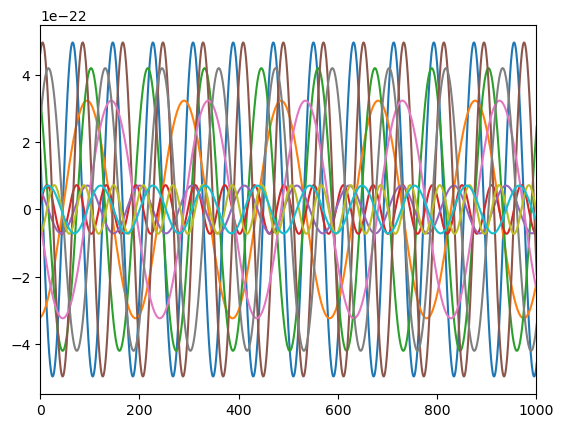

In [6]:
plt.plot(data_waveforms.get().real)
plt.plot(data_waveforms.get().imag)
plt.xlim(0,1e3)
plt.show()

In [7]:
N_traj = 5e3
delta_T = T * YRSID_SI / N_traj
delta_T

525.9691627257598

In [8]:
_, p, e, x, _, _, _ = traj(m1, m2, a, p0, e0, xI0, 
                            T=T, dt=delta_T, upsample=True, 
                            Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0)    

In [9]:
teuk_modes = amp(a, p, e, x)

In [10]:
def _get_viewing_angles(qS, phiS, qK, phiK):
    """Transform from the detector frame to the source  frame"""
    cqS = np.cos(qS)
    sqS = np.sin(qS)
    cphiS = np.cos(phiS)
    sphiS = np.sin(phiS)
    cqK = np.cos(qK)
    sqK = np.sin(qK)
    cphiK = np.cos(phiK)
    sphiK = np.sin(phiK)
    # sky location vector
    R = np.array([sqS * cphiS, sqS * sphiS, cqS])
    # spin vector
    S = np.array([sqK * cphiK, sqK * sphiK, cqK])
    # get viewing angles
    phi = -np.pi / 2.0  # by definition of source frame
    theta = np.arccos(-np.dot(R, S))  # normalized vector

    return (theta, phi)

In [11]:
qS, phiS, qK, phiK

(0.5, 1, 1, 2.0471975511965974)

In [12]:
theta, phi = _get_viewing_angles(qS, phiS, qK, phiK)
ylms = ylm_gen(amp.unique_l, amp.unique_m, theta, phi).copy()[amp.inverse_lm]

In [13]:
params = [np.log10(m1), np.log10(m2), a, p0, e0]

In [14]:
OmegaPhi, _, OmegaR = get_fundamental_frequencies(a, p, e, x)
gw_frequencies_per_mode = []
for idx in range(len(amp.l_arr)):
    m = amp.m_arr[idx]
    n = amp.n_arr[idx]

    m = m.get() if isinstance(m, cp.ndarray) else m
    n = n.get() if isinstance(n, cp.ndarray) else n

    # Calculate GW frequencies
    f_gw = m * OmegaPhi + n * OmegaR
    gw_frequencies_per_mode.append(f_gw)

In [15]:
m0mask = amp.m_arr_no_mask != 0

In [16]:
total_power = gwf.calc_power(teuk_modes, ylms, m0mask, 
                                    m1=params[0], m2=params[1], 
                                    gw_freqs=gw_frequencies_per_mode)

In [17]:
mode_labels = []
for l, m, n in zip(amp.l_arr, amp.m_arr, amp.n_arr):
    l_int = l.item() if hasattr(l, 'item') else int(l)
    m_int = m.item() if hasattr(m, 'item') else int(m)
    n_int = n.item() if hasattr(n, 'item') else int(n)
    mode_labels.append((l_int, m_int, n_int))

In [18]:
# Top M_init indices in descending order (based on power)
M_init = 5 
top_indices = gwf.xp.argsort(total_power)[-M_init:][::-1] 
top_indices = top_indices.get() if isinstance(top_indices, cp.ndarray) else top_indices

# Get sorted mode labels and power values
# TODO: noise-weighted power mode selection?
mp_modes = [mode_labels[idx] for idx in top_indices]
mp_power = total_power[top_indices]

In [19]:
mp_power

array([2.15440680e+34, 4.20971724e+33, 3.03881494e+33, 1.32370914e+33,
       8.16648425e+32])

In [20]:
mp_modes

[(2, -2, 2), (2, -2, 3), (2, -2, 1), (5, -5, 6), (3, -3, 4)]

# 1 mth

In [21]:
loglike_obj_1mth = loglikegen.LogLike(params_star, 
                                   waveform_gen_comb, 
                                   gwf, 
                                #    mode_select = selected_labels,
                                   verbose=True, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=5,
                                   M_mode=5
                                   )
data_1mth = loglike_obj_1mth.signal
print("SNR: ", gwf.rhostat(data_1mth))

Delta_T for mode selection: 525.9691627257598 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, 1) with power 37.752389672860716
Considering mode 1 / 5 : (2, -2, 0) with power 27.219534290131172
 - Overlap with selected mode 0: 0.00019610327595891042
Considering mode 2 / 5 : (2, -2, 2) with power 21.52742839168892
 - Overlap with selected mode 0: 0.00019483872499444178
 - Overlap with selected mode 1: 0.0
Considering mode 3 / 5 : (2, -2, -1) with power 15.9743579425701
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.00019623654709587356
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (2, -2, 3) with power 8.941730182891215
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.0
 - Overlap with selected mode 2: 0.00019604363732625096
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, 1)], [(2, -2, 0)], [(2, -2, 2)], [(2, -2, -1)], [(2, -2, 3)]]
Number of mode groups returned: 5
Selected

In [22]:
proc1_pt = (10**6.02680358,  10**1.46982606,  0.7897165 , 14.39679547,  0.39827987, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
loglike_obj_1mth_proc1 = loglikegen.LogLike(proc1_pt, 
                                   waveform_gen_comb, 
                                   gwf, 
                                #    mode_select = selected_labels,
                                   verbose=True, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=5,
                                   M_mode=5
                                   )

Delta_T for mode selection: 525.9691627257598 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, 1) with power 40.668869406005875
Considering mode 1 / 5 : (2, -2, 0) with power 29.87924386575527
 - Overlap with selected mode 0: 0.00019611094899071104
Considering mode 2 / 5 : (2, -2, 2) with power 22.86195028093764
 - Overlap with selected mode 0: 0.0001948662010334123
 - Overlap with selected mode 1: 0.0
Considering mode 3 / 5 : (2, -2, -1) with power 17.04543153034018
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.00019625216256359695
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (2, -2, 3) with power 9.367572456407997
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.0
 - Overlap with selected mode 2: 0.00019597666698572646
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, 1)], [(2, -2, 0)], [(2, -2, 2)], [(2, -2, -1)], [(2, -2, 3)]]
Number of mode groups returned: 5
Selected 

In [23]:
proc2_pt = (10**5.93845955,  10**1.50506177,  0.45790577, 16.56223858,  0.39802901, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
loglike_obj_1mth_proc2 = loglikegen.LogLike(proc2_pt, 
                                   waveform_gen_comb, 
                                   gwf, 
                                #    mode_select = selected_labels,
                                   verbose=True, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=5,
                                   M_mode = 5
                                   )


Delta_T for mode selection: 525.9691627257598 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, 1) with power 31.995016909300944
Considering mode 1 / 5 : (2, -2, 0) with power 23.14735499118469


 - Overlap with selected mode 0: 0.00019612585964614066
Considering mode 2 / 5 : (2, -2, 2) with power 18.22213963696447
 - Overlap with selected mode 0: 0.00019477494422397932
 - Overlap with selected mode 1: 0.0
Considering mode 3 / 5 : (2, -2, -1) with power 13.466466903332705
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.0001962581517350031
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (2, -2, 3) with power 7.565938334961439
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.0
 - Overlap with selected mode 2: 0.00019619665302708487
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, 1)], [(2, -2, 0)], [(2, -2, 2)], [(2, -2, -1)], [(2, -2, 3)]]
Number of mode groups returned: 5
Selected modes: [[(2, -2, 1)], [(2, -2, 0)], [(2, -2, 2)], [(2, -2, -1)], [(2, -2, 3)]]
Number of selected modes: 5
Flattened modes: [(2, -2, 1), (2, -2, 0), (2, -2, 2), (2, -2, -1), (2, -2, 3)]
Selected modes structure: [[7160],

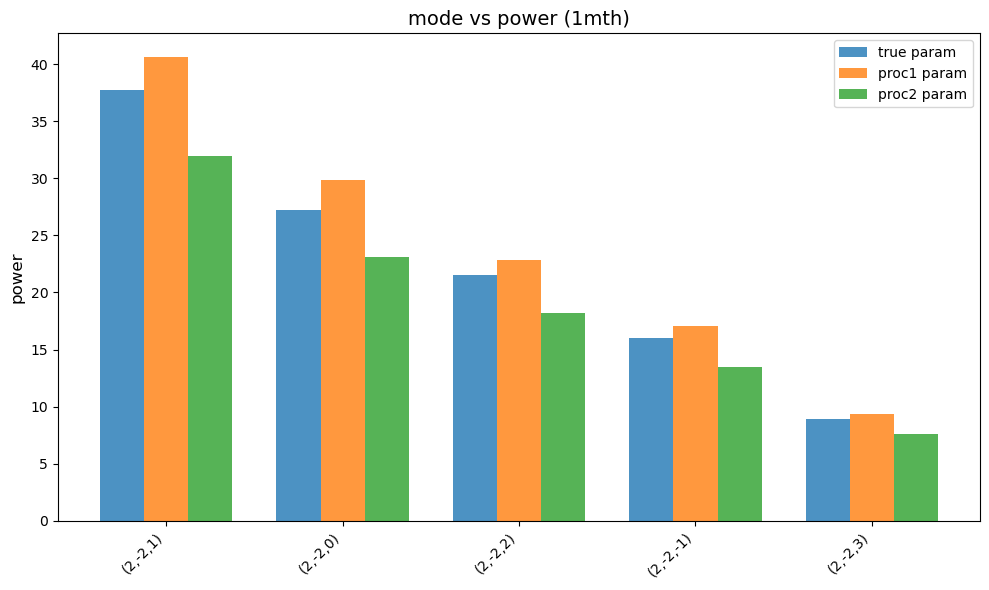

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your output
modes = ['(2,-2,1)', '(2,-2,0)', '(2,-2,2)', '(2,-2,-1)', '(2,-2,3)']

# True param powers
true_powers = [37.752389672860716, 27.219534290131172, 21.52742839168892, 
               15.9743579425701, 8.941730182891215]

# Proc1 param powers
proc1_powers = [40.668869406005875, 29.87924386575527, 22.86195028093764,
                17.04543153034018, 9.367572456407997]

# Proc2 param powers
proc2_powers = [31.995016909300944, 23.14735499118469, 18.22213963696447,
                13.466466903332705, 7.565938334961439]

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(modes))
width = 0.25

ax.bar(x - width, true_powers, width, label='true param', alpha=0.8)
ax.bar(x, proc1_powers, width, label='proc1 param', alpha=0.8)
ax.bar(x + width, proc2_powers, width, label='proc2 param', alpha=0.8)

# ax.set_xlabel('Mode', fontsize=12)
ax.set_ylabel('power', fontsize=12)
ax.set_title('mode vs power (1mth)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(modes, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

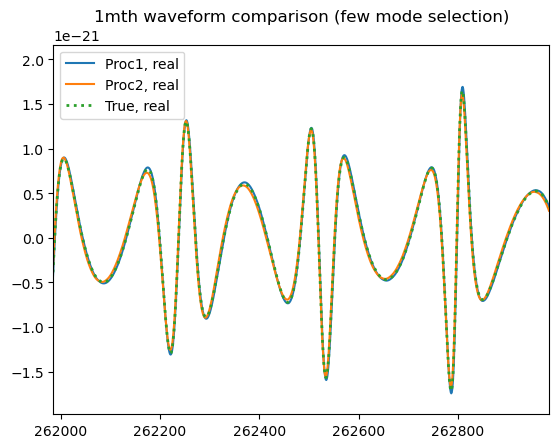

In [65]:
plt.plot(loglike_obj_1mth_proc1.signal.get().real, label='Proc1, real')
plt.plot(loglike_obj_1mth_proc2.signal.get().real, label='Proc2, real')
plt.plot(loglike_obj_1mth.signal.get().real, label='True, real', linewidth=2, linestyle='dotted')
plt.xlim(len(true_wave_1mth.get().real)-1e3, len(true_wave_1mth.get().real))
plt.title('1mth waveform comparison (few mode selection)')
plt.legend()
plt.show()

In [62]:
true_wave_1mth = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                   qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                                   T=1/12, dt=10, mode_selection=selected_labels, include_minus_mkn=False)

proc1_wave_1mth = waveform_gen_comb(10**6.02680358,  10**1.46982606,  0.7897165 , 14.39679547,  0.39827987, xI0, dist, 
                                   qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                                   T=1/12, dt=10, mode_selection=selected_labels, include_minus_mkn=False)

proc2_wave_1mth = waveform_gen_comb(10**5.93845955,  10**1.50506177,  0.45790577, 16.56223858,  0.39802901, xI0, dist, 
                                   qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                                   T=1/12, dt=10, mode_selection=selected_labels, include_minus_mkn=False)

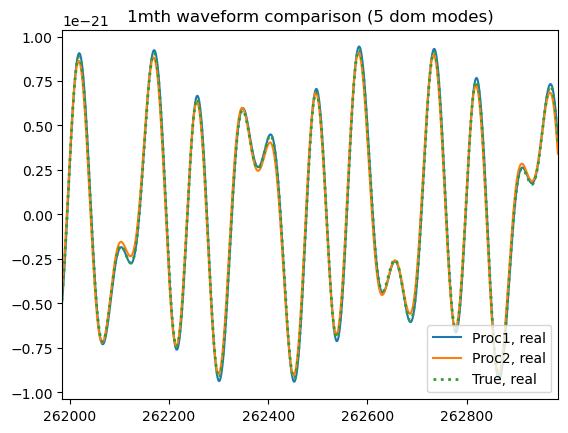

In [63]:
plt.plot(proc1_wave_1mth.get().real, label='Proc1, real')
plt.plot(proc2_wave_1mth.get().real, label='Proc2, real')
plt.plot(true_wave_1mth.get().real, label='True, real', linewidth=2, linestyle='dotted')
plt.title('1mth waveform comparison (5 dom modes)')
plt.xlim(len(true_wave_1mth.get().real)-1e3, len(true_wave_1mth.get().real))
plt.legend()
plt.show()

# 3 hrs

In [31]:
gwf_3hr = GWfuncs.GravWaveAnalysis(1/2922, dt) 

In [33]:
loglike_obj_3hr = loglikegen.LogLike(params_star, 
                                   waveform_gen_comb, 
                                   gwf_3hr, 
                                #    mode_select = selected_labels,
                                   verbose=True, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=5,
                                   M_mode=5
                                   )
# data_3hr = loglike_obj_3hr.signal
# print("SNR: ", gwf.rhostat(data_3hr))

Delta_T for mode selection: 2.160037629263901 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, 1) with power 37.53236870277393
Considering mode 1 / 5 : (2, -2, 0) with power 26.87245817932137
 - Overlap with selected mode 0: 0.020372670525296108
Considering mode 2 / 5 : (2, -2, 2) with power 21.519042286471183
 - Overlap with selected mode 0: 0.0072773885190578445
Considering mode 3 / 5 : (2, -2, -1) with power 15.938719201682076
 - Overlap with selected mode 0: 0.019183444018024565
 - Overlap with selected mode 1: 0.0
Considering mode 4 / 5 : (2, -2, 3) with power 8.985514564217992
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.020289803001185196
Final selected labels: [[(2, -2, 1), (2, -2, 0), (2, -2, -1)], [(2, -2, 2), (2, -2, 3)]]
Number of mode groups returned: 2
Selected modes: [[(2, -2, 1), (2, -2, 0), (2, -2, -1)], [(2, -2, 2), (2, -2, 3)]]
Number of selected modes: 2
Flattened modes: [(2, -2, 1), (2, -2, 0), (2, -2, -1), (2,

In [57]:
loglike_obj_3hr_proc1 = loglikegen.LogLike(proc1_pt, 
                                   waveform_gen_comb, 
                                   gwf_3hr, 
                                #    mode_select = selected_labels,
                                   verbose=True, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=5,
                                   M_mode=5
                                   )


Delta_T for mode selection: 2.160037629263901 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, 1) with power 40.43648759289391
Considering mode 1 / 5 : (2, -2, 0) with power 29.500860124304168
 - Overlap with selected mode 0: 0.0203709628440974
Considering mode 2 / 5 : (2, -2, 2) with power 22.85668207474282
 - Overlap with selected mode 0: 0.007185838420053758
Considering mode 3 / 5 : (2, -2, -1) with power 17.00905770713802
 - Overlap with selected mode 0: 0.019215171096603992
 - Overlap with selected mode 1: 0.0
Considering mode 4 / 5 : (2, -2, 3) with power 9.415355695564754
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.020278823852732844
Final selected labels: [[(2, -2, 1), (2, -2, 0), (2, -2, -1)], [(2, -2, 2), (2, -2, 3)]]
Number of mode groups returned: 2
Selected modes: [[(2, -2, 1), (2, -2, 0), (2, -2, -1)], [(2, -2, 2), (2, -2, 3)]]
Number of selected modes: 2
Flattened modes: [(2, -2, 1), (2, -2, 0), (2, -2, -1), (2, -2,

In [58]:
loglike_obj_3hr_proc2 = loglikegen.LogLike(proc2_pt, 
                                   waveform_gen_comb, 
                                   gwf_3hr, 
                                #    mode_select = selected_labels,
                                   verbose=True, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=5,
                                   M_mode=5
                                   )


Delta_T for mode selection: 2.160037629263901 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, 1) with power 31.80756803068476
Considering mode 1 / 5 : (2, -2, 0) with power 22.854515277604897
 - Overlap with selected mode 0: 0.020376370041609332
Considering mode 2 / 5 : (2, -2, 2) with power 18.213271538328875
 - Overlap with selected mode 0: 0.00725162076685487
Considering mode 3 / 5 : (2, -2, -1) with power 13.434617142293417
 - Overlap with selected mode 0: 0.019195593018595237
 - Overlap with selected mode 1: 0.0
Considering mode 4 / 5 : (2, -2, 3) with power 7.601864473749293
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.02031147981413713
Final selected labels: [[(2, -2, 1), (2, -2, 0), (2, -2, -1)], [(2, -2, 2), (2, -2, 3)]]
Number of mode groups returned: 2
Selected modes: [[(2, -2, 1), (2, -2, 0), (2, -2, -1)], [(2, -2, 2), (2, -2, 3)]]
Number of selected modes: 2
Flattened modes: [(2, -2, 1), (2, -2, 0), (2, -2, -1), (2, -

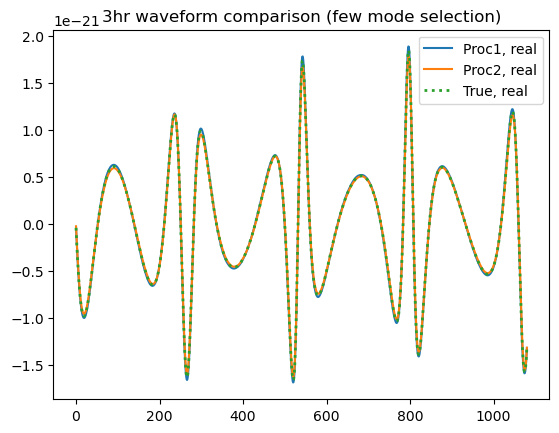

In [59]:
plt.plot(loglike_obj_3hr_proc1.signal.get().real, label='Proc1, real')
plt.plot(loglike_obj_3hr_proc2.signal.get().real, label='Proc2, real')
plt.plot(loglike_obj_3hr.signal.get().real, label='True, real', linewidth=2, linestyle='dotted')
plt.title('3hr waveform comparison (few mode selection)')
plt.legend()
plt.show()

In [36]:
selected_labels = [(2, -2, 1), (2, -2, 0), (2, -2, -1), (2, -2, 2), (2, -2, 3)]
true_wave = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                   qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                                   T=1/2922, dt=10, mode_selection=selected_labels, include_minus_mkn=False)

In [37]:
proc1_wave = waveform_gen_comb(10**6.02680358,  10**1.46982606,  0.7897165 , 14.39679547,  0.39827987, xI0, dist, 
                                   qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                                   T=1/2922, dt=10, mode_selection=selected_labels, include_minus_mkn=False)

In [38]:
proc2_wave = waveform_gen_comb(10**5.93845955,  10**1.50506177,  0.45790577, 16.56223858,  0.39802901, xI0, dist, 
                                   qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                                   T=1/2922, dt=10, mode_selection=selected_labels, include_minus_mkn=False)

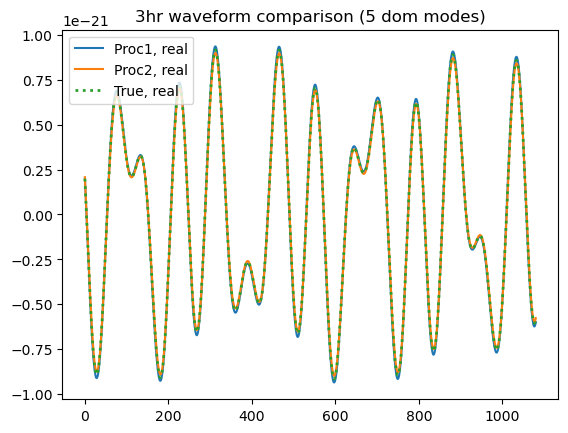

In [60]:
plt.plot(proc1_wave.get().real, label='Proc1, real')
plt.plot(proc2_wave.get().real, label='Proc2, real')
plt.plot(true_wave.get().real, label='True, real', linewidth=2, linestyle='dotted')
plt.title("3hr waveform comparison (5 dom modes)")
plt.legend()
plt.show()

# 2 yr

In [41]:
gwf_2yr = GWfuncs.GravWaveAnalysis(2, dt)

In [42]:
loglike_obj_2yr = loglikegen.LogLike(params_star, 
                                   waveform_gen_comb, 
                                   gwf_2yr, 
                                #    mode_select = selected_labels,
                                   verbose=True, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=5
                                   )


Delta_T for mode selection: 12623.259905418237 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, 1) with power 43.2701560457758
Considering mode 1 / 5 : (2, -2, 0) with power 37.769819806706536
 - Overlap with selected mode 0: 0.00012058379560256994
Considering mode 2 / 5 : (2, -2, 2) with power 21.303309780537944
 - Overlap with selected mode 0: 0.00010025941821622614
 - Overlap with selected mode 1: 0.0
Considering mode 3 / 5 : (2, -2, -1) with power 16.81982797213372
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.00012083765202903962
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (2, -2, 3) with power 7.72846939486087
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.0
 - Overlap with selected mode 2: 0.00013109381843751303
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, 1)], [(2, -2, 0)], [(2, -2, 2)], [(2, -2, -1)], [(2, -2, 3)]]
Number of mode groups returned: 5
Selected

In [43]:
loglike_obj_2yr_proc1 = loglikegen.LogLike(proc1_pt, 
                                   waveform_gen_comb, 
                                   gwf_2yr, 
                                #    mode_select = selected_labels,
                                   verbose=True, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=5
                                   )


Delta_T for mode selection: 12623.259905418237 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, 1) with power 46.45930195305725
Considering mode 1 / 5 : (2, -2, 0) with power 41.347297226198016
 - Overlap with selected mode 0: 0.00012109224066045905
Considering mode 2 / 5 : (2, -2, 2) with power 22.52916746164627
 - Overlap with selected mode 0: 0.00010150745797981583
 - Overlap with selected mode 1: 0.0
Considering mode 3 / 5 : (2, -2, -1) with power 17.897938143613906
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.00012133010343210983
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (2, -2, 3) with power 8.056388485273544
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.0
 - Overlap with selected mode 2: 0.00013203504485992504
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, 1)], [(2, -2, 0)], [(2, -2, 2)], [(2, -2, -1)], [(2, -2, 3)]]
Number of mode groups returned: 5
Select

In [44]:
loglike_obj_2yr_proc2 = loglikegen.LogLike(proc2_pt, 
                                   waveform_gen_comb, 
                                   gwf_2yr, 
                                #    mode_select = selected_labels,
                                   verbose=True, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   M_init=5
                                   )


Delta_T for mode selection: 12623.259905418237 seconds
Generating modes at initialization...
Initial mode selected: (2, -2, 1) with power 36.738701223135145
Considering mode 1 / 5 : (2, -2, 0) with power 32.08440731352136
 - Overlap with selected mode 0: 0.00012006506896045227
Considering mode 2 / 5 : (2, -2, 2) with power 18.087396273424154
 - Overlap with selected mode 0: 9.7426765187401e-05
 - Overlap with selected mode 1: 0.0
Considering mode 3 / 5 : (2, -2, -1) with power 14.239040388557482
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.000120618562359782
 - Overlap with selected mode 2: 0.0
Considering mode 4 / 5 : (2, -2, 3) with power 6.563801425873733
 - Overlap with selected mode 0: 0.0
 - Overlap with selected mode 1: 0.0
 - Overlap with selected mode 2: 0.00012937060470253174
 - Overlap with selected mode 3: 0.0
Final selected labels: [[(2, -2, 1)], [(2, -2, 0)], [(2, -2, 2)], [(2, -2, -1)], [(2, -2, 3)]]
Number of mode groups returned: 5
Selected m

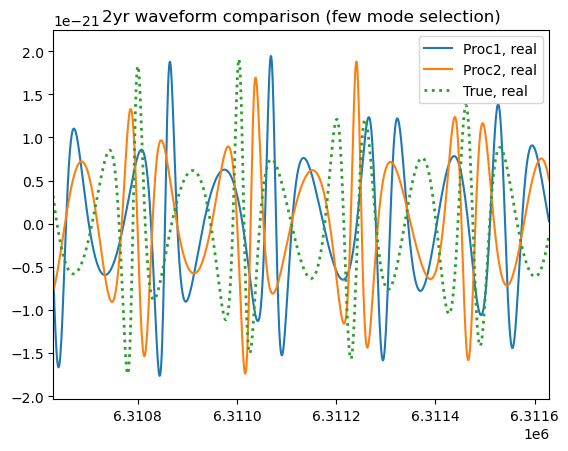

In [53]:
plt.plot(loglike_obj_2yr_proc1.signal.get().real, label='Proc1, real')
plt.plot(loglike_obj_2yr_proc2.signal.get().real, label='Proc2, real')
plt.plot(loglike_obj_2yr.signal.get().real, label='True, real', linewidth=2, linestyle='dotted')
plt.xlim(len(loglike_obj_2yr.signal.get().real)-1e3, len(loglike_obj_2yr.signal.get().real))
plt.title('2yr waveform comparison (few mode selection)')
plt.legend()
plt.show()

In [49]:
true_wave_2yr = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                   qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                                   T=2, dt=10, mode_selection=selected_labels, include_minus_mkn=False)

proc1_wave_2yr = waveform_gen_comb(10**6.02680358,  10**1.46982606,  0.7897165 , 14.39679547,  0.39827987, xI0, dist, 
                                   qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                                   T=2, dt=10, mode_selection=selected_labels, include_minus_mkn=False)

proc2_wave_2yr = waveform_gen_comb(10**5.93845955,  10**1.50506177,  0.45790577, 16.56223858,  0.39802901, xI0, dist, 
                                   qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, 
                                   T=2, dt=10, mode_selection=selected_labels, include_minus_mkn=False)

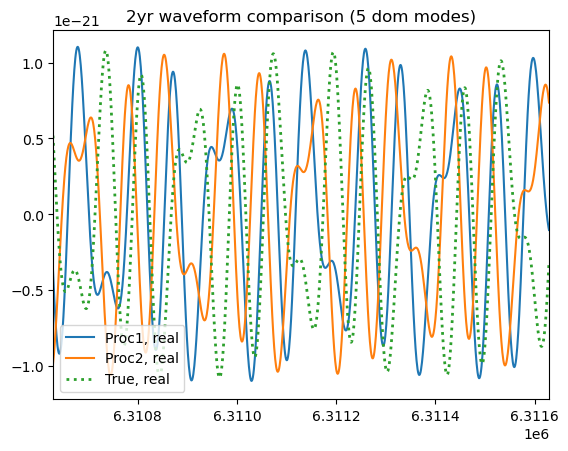

In [52]:
plt.plot(proc1_wave_2yr.get().real, label='Proc1, real')
plt.plot(proc2_wave_2yr.get().real, label='Proc2, real')
plt.plot(true_wave_2yr.get().real, label='True, real', linewidth=2, linestyle='dotted')
plt.title('2yr waveform comparison (5 dom modes)')
plt.xlim(len(true_wave_2yr.get().real)-1e3, len(true_wave_2yr.get().real))
plt.legend()
plt.show()